In [1]:
import pandas as pd #Biblioteca para Dataframes (planilhas)
import numpy as np #Para operações matemáticas

import io
from google.colab import files

import matplotlib.pyplot as plt #matplotlib desenha gráficos
import matplotlib.colors as colors
from sklearn.utils import resample #sklearn trabalha com a implementação de algoritmos ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from datetime import date, datetime

In [2]:
from collections import defaultdict
for i in range(2010,2026,1):

  url = "https://info.dengue.mat.br/api/alertcity"
  geocode = 2927408
  disease = "dengue"
  format = "csv"
  ew_start = 1
  ew_end = 53
  ey_start = i
  ey_end = i

  params =(
      "&disease="
      + f"{disease}"
      + "&geocode="
      + f"{geocode}"
      + "&disease="
      + f"{disease}"
      + "&format="
      + f"{format}"
      + "&ew_start="
      + f"{ew_start}"
      + "&ew_end="
      + f"{ew_end}"
      + "&ey_start="
      + f"{ey_start}"
      + "&ey_end="
      + f"{ey_end}"
  )

  url_resp = "?".join([url, params])
  if i == 2010:
    df = pd.read_csv(url_resp, index_col='SE')
  else:
    dadosNew = pd.read_csv(url_resp, index_col='SE')
    df = pd.concat([dadosNew, df])
df

,data_iniSE,casos_est,casos_est_min,casos_est_max,casos,p_rt1,p_inc100k,Localidade_id,nivel,id,...,umidmed,umidmin,tempmed,tempmax,casprov,casprov_est,casprov_est_min,casprov_est_max,casconf,notif_accum_year
SE,,,,,,,,,,,,,,,,,,,,,
202516,2025-04-13,120.0,64,256,28,0.278110,4.595963,0,2,292740820251620200,...,78.720975,69.622950,27.238650,28.903425,28.0,NaN,NaN,NaN,NaN,1484
202515,2025-04-06,132.0,104,184,87,0.678999,5.055560,0,2,292740820251520200,...,78.882029,71.485629,26.734286,28.151686,83.0,NaN,NaN,NaN,NaN,1484
202514,2025-03-30,137.0,120,168,110,0.869275,5.247058,0,2,292740820251420200,...,77.756743,67.724686,26.946629,28.723957,91.0,NaN,NaN,NaN,NaN,1484
202513,2025-03-23,120.0,109,140,104,0.701813,4.595963,0,2,292740820251320200,...,77.479857,66.078743,26.932686,28.892971,80.0,NaN,NaN,NaN,NaN,1484
202512,2025-03-16,123.0,116,135,114,0.880733,4.710862,0,2,292740820251220200,...,78.147971,70.011829,26.947957,28.603486,70.0,NaN,NaN,NaN,NaN,1484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201005,2010-01-31,118.0,118,118,118,0.000000,4.087716,0,2,292740820100519589,...,74.697437,60.142857,28.655242,31.285714,118.0,NaN,NaN,NaN,NaN,9227
201004,2010-01-24,69.0,69,69,69,0.000000,2.390274,0,2,292740820100419589,...,76.221839,61.857143,28.148011,30.857143,69.0,NaN,NaN,NaN,NaN,9227
201003,2010-01-17,57.0,57,57,57,0.000000,1.974574,0,2,292740820100319589,...,80.623241,66.857143,27.698323,30.142857,57.0,NaN,NaN,NaN,NaN,9227


In [3]:
df['data_iniSE'] = pd.to_datetime(df['data_iniSE'])
df = df.loc[:, ['data_iniSE', 'nivel_inc', 'casos', 'pop', 'tempmax', 'umidmax']]
df = df.iloc[::-1] #Inverte a ordem das linhas
df

,data_iniSE,nivel_inc,casos,pop,tempmax,umidmax
SE,,,,,,
201001,2010-01-03,1,60,2886698,30.428571,96.714286
201002,2010-01-10,1,52,2886698,30.571429,96.714286
201003,2010-01-17,1,57,2886698,30.142857,93.714286
201004,2010-01-24,1,69,2886698,30.857143,88.142857
201005,2010-01-31,1,118,2886698,31.285714,86.142857
...,...,...,...,...,...,...
202512,2025-03-16,1,114,2610987,28.603486,86.588529
202513,2025-03-23,1,104,2610987,28.892971,86.811457
202514,2025-03-30,1,110,2610987,28.723957,86.730443


In [4]:
df['nivel_inc'] = [0 if x == 0 or x == 1 else 1 for x in df['nivel_inc']]

In [5]:
OG_df = df.copy()

In [6]:
def create_time_series_variables(df, columns, time_periods):
    df = df.copy()

    for col in columns:
        for period in time_periods:
            lag_col_name = f"{col}_lag_{period}w"
            df[lag_col_name] = df[col].shift(period)

    return df

In [7]:
time_periods = [1]
columns = ['nivel_inc']
df = create_time_series_variables(OG_df, columns, time_periods)
time_periods = [12]
columns = ['casos', 'pop', 'tempmax', 'umidmax']
df = create_time_series_variables(df, columns, time_periods)
df.drop(columns, axis=1, inplace=True)
df

,data_iniSE,nivel_inc,nivel_inc_lag_1w,casos_lag_12w,pop_lag_12w,tempmax_lag_12w,umidmax_lag_12w
SE,,,,,,,
201001,2010-01-03,0,NaN,NaN,NaN,NaN,NaN
201002,2010-01-10,0,0.0,NaN,NaN,NaN,NaN
201003,2010-01-17,0,0.0,NaN,NaN,NaN,NaN
201004,2010-01-24,0,0.0,NaN,NaN,NaN,NaN
201005,2010-01-31,0,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
202512,2025-03-16,0,0.0,81.0,2610987.0,29.865657,81.694800
202513,2025-03-23,0,0.0,60.0,2610987.0,30.199243,81.818771
202514,2025-03-30,0,0.0,90.0,2610987.0,29.712371,86.305286


In [8]:
df.set_index('data_iniSE', inplace= True)
df = df.iloc[12:]
df

,nivel_inc,nivel_inc_lag_1w,casos_lag_12w,pop_lag_12w,tempmax_lag_12w,umidmax_lag_12w
data_iniSE,,,,,,
2010-03-28,0,0.0,60.0,2886698.0,30.428571,96.714286
2010-04-04,0,0.0,52.0,2886698.0,30.571429,96.714286
2010-04-11,0,0.0,57.0,2886698.0,30.142857,93.714286
2010-04-18,0,0.0,69.0,2886698.0,30.857143,88.142857
2010-04-25,1,0.0,118.0,2886698.0,31.285714,86.142857
...,...,...,...,...,...,...
2025-03-16,0,0.0,81.0,2610987.0,29.865657,81.694800
2025-03-23,0,0.0,60.0,2610987.0,30.199243,81.818771
2025-03-30,0,0.0,90.0,2610987.0,29.712371,86.305286


In [9]:
# Deletar
df.dropna(inplace=True)
df

<ipython-input-9-ec876a52b89c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


,nivel_inc,nivel_inc_lag_1w,casos_lag_12w,pop_lag_12w,tempmax_lag_12w,umidmax_lag_12w
data_iniSE,,,,,,
2010-03-28,0,0.0,60.0,2886698.0,30.428571,96.714286
2010-04-04,0,0.0,52.0,2886698.0,30.571429,96.714286
2010-04-11,0,0.0,57.0,2886698.0,30.142857,93.714286
2010-04-18,0,0.0,69.0,2886698.0,30.857143,88.142857
2010-04-25,1,0.0,118.0,2886698.0,31.285714,86.142857
...,...,...,...,...,...,...
2025-03-16,0,0.0,81.0,2610987.0,29.865657,81.694800
2025-03-23,0,0.0,60.0,2610987.0,30.199243,81.818771
2025-03-30,0,0.0,90.0,2610987.0,29.712371,86.305286


In [10]:
train, test = df[:-156], df[-156:]

predictors = df.columns.drop(['nivel_inc'])
target = 'nivel_inc'

scaler = StandardScaler()

train.loc[:,predictors] = scaler.fit_transform(train[predictors])
test.loc[:,predictors] = scaler.fit_transform(test[predictors])

In [11]:
from sklearn.metrics import accuracy_score
def test_model(Real, Predictions):
  Predictions = Predictions.astype(int)
  acc = accuracy_score(Real, Predictions)
  print(f"Accuracy_Score = {acc*100}%")

  FP, TP, FN, TN = 0,0,0,0
  for real_value, predicted_value in zip(Real, Predictions):
    if real_value == 1:
      if predicted_value == 1:
        TP += 1
      else:
        FN += 1
    elif predicted_value == 1:
      FP += 1
    else:
      TN += 1

  sensitivity = TP / (TP + FN)
  specificity = TN / (TN + FP)
  print(f"Sensitivity_Score = {sensitivity*100}%\nSpecificity_Score = {specificity*100}%")

  test = pd.DataFrame()
  test["Reais"], test["Previstos"] = Real, Predictions
  combined = pd.concat([test["Reais"], test["Previstos"]], axis=1)
  combined.plot(title="Epidemia em Salvador", ylabel= "Nível epidêmico", xlabel="Data")

#Backtest

In [12]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train[target])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test[target], preds], axis=1)
    return combined

In [13]:
def backtest(data, model, predictors, start=468, step=1):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)

        if not predictions.empty:
            prediction_value = predictions.at[predictions.index[0], 'Predictions']

            if i + step < data.shape[0]:
                data.iloc[i + step, df.columns.get_loc('nivel_inc_lag_1w')] = prediction_value

        all_predictions.append(predictions)

    return pd.concat(all_predictions)

In [14]:
from sklearn.svm import SVC
model = SVC(kernel="rbf", gamma=0.1, C=1000, random_state=1)
predictions = backtest(df.copy(), model, predictors)

SVC
Accuracy_Score = 84.56375838926175%
Sensitivity_Score = 83.33333333333334%
Specificity_Score = 85.09615384615384%


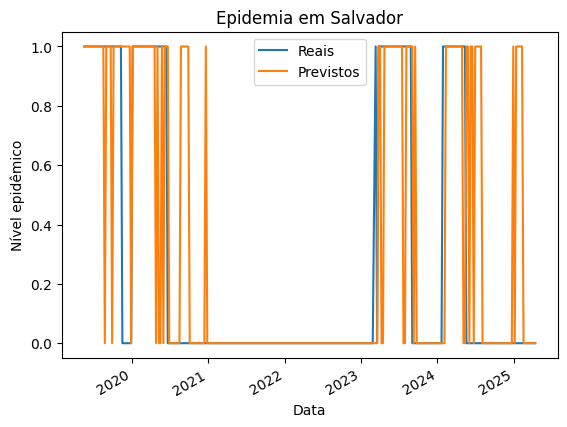

In [15]:
print("SVC")
test_model(predictions[target], predictions["Predictions"])

In [16]:
def customGridSearch(df, predictors, target, param_grid):
  i = 0
  best_accuracy = 0
  best_params = {'kernel': None, 'C': None,'gamma': None}
  for kernel in param_grid['kernel']:
    for C in param_grid['C']:
      for gamma in param_grid['gamma']:
        model = SVC(kernel=kernel, gamma=gamma, C=C, random_state=1)
        predictions = backtest(df.copy(), model, predictors)
        accuracy = accuracy_score(predictions[target], predictions['Predictions'])
        print(f"{i}: [kernel: {kernel}, C: {C}, gamma: {gamma}]")
        if accuracy > best_accuracy:
          best_accuracy = accuracy
          best_params['kernel'], best_params['C'], best_params['gamma'] = kernel, C, gamma
        i += 1
  return best_params

In [17]:
param_grid = {'kernel': ["rbf"],
          'C': [1,5,10,15,50,100,1000,1500, 2000, 2500, 3000],
          'gamma': [1e-4, 1e-3, 1e-2, 1e-1, 0.5]
              }
best_params = customGridSearch(df.copy(), predictors, target, param_grid)

0: [kernel: rbf, C: 1, gamma: 0.0001]
1: [kernel: rbf, C: 1, gamma: 0.001]
2: [kernel: rbf, C: 1, gamma: 0.01]
3: [kernel: rbf, C: 1, gamma: 0.1]
4: [kernel: rbf, C: 1, gamma: 0.5]
5: [kernel: rbf, C: 5, gamma: 0.0001]
6: [kernel: rbf, C: 5, gamma: 0.001]
7: [kernel: rbf, C: 5, gamma: 0.01]
8: [kernel: rbf, C: 5, gamma: 0.1]
9: [kernel: rbf, C: 5, gamma: 0.5]
10: [kernel: rbf, C: 10, gamma: 0.0001]
11: [kernel: rbf, C: 10, gamma: 0.001]
12: [kernel: rbf, C: 10, gamma: 0.01]
13: [kernel: rbf, C: 10, gamma: 0.1]
14: [kernel: rbf, C: 10, gamma: 0.5]
15: [kernel: rbf, C: 15, gamma: 0.0001]
16: [kernel: rbf, C: 15, gamma: 0.001]
17: [kernel: rbf, C: 15, gamma: 0.01]
18: [kernel: rbf, C: 15, gamma: 0.1]
19: [kernel: rbf, C: 15, gamma: 0.5]
20: [kernel: rbf, C: 50, gamma: 0.0001]
21: [kernel: rbf, C: 50, gamma: 0.001]
22: [kernel: rbf, C: 50, gamma: 0.01]
23: [kernel: rbf, C: 50, gamma: 0.1]
24: [kernel: rbf, C: 50, gamma: 0.5]
25: [kernel: rbf, C: 100, gamma: 0.0001]
26: [kernel: rbf, C: 100

In [18]:
print(best_params)

{'kernel': 'rbf', 'C': 3000, 'gamma': 0.01}


In [19]:
model = SVC(kernel=best_params['kernel'], C=best_params['C'], gamma=best_params['gamma'], random_state=1)
predictions = backtest(df.copy(), model, predictors)

SVC_Optimized
Accuracy_Score = 93.6241610738255%
Sensitivity_Score = 91.11111111111111%
Specificity_Score = 94.71153846153845%


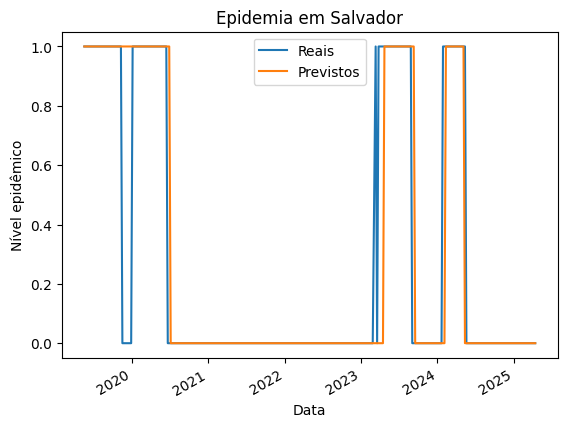

In [20]:
print("SVC_Optimized")
test_model(predictions[target], predictions["Predictions"])